<div style="border-bottom: 2px solid #1f2a44; padding-bottom: 14px; margin-bottom: 22px;">
  <div style="display: flex; align-items: center; justify-content: space-between; gap: 24px;">
    <img src="../assets/branding/logoUgrupo.png" alt="Universidad del Magdalena y GIDSYC" style="height: 76px; max-width: 34%; object-fit: contain;">
    <div style="text-align: center; flex: 1; min-width: 260px;">
      <div style="font-size: 14px; letter-spacing: 0.04em; text-transform: uppercase; color: #5b6472;">Modelos de difusión para IA generativa</div>
      <div style="font-size: 15px; font-weight: 700; color: #667085; margin-top: 6px;">Notebook 11</div>
      <div style="font-size: 26px; font-weight: 700; color: #1f2a44; margin-top: 2px;">Espacios latentes y arquitecturas generativas modernas</div>
      <div style="font-size: 14px; color: #5b6472; margin-top: 8px;">Semillero GIDSYC | Facultad de Ingenierías | Programa de Ingeniería de Sistemas</div>
    </div>
    <img src="../assets/branding/logo_semillero.png" alt="Semillero GIDSYC" style="height: 74px; object-fit: contain;">
  </div>
</div>

<div style="display: flex; justify-content: space-between; gap: 16px; color: #3f4754; font-size: 14px; margin-bottom: 20px; flex-wrap: wrap;">
  <div><strong>Grupo:</strong> GIDSYC</div>
  <div><strong>Unidad:</strong> Semillero GIDSYC</div>
  <div><strong>Universidad:</strong> Universidad del Magdalena</div>
  <div><strong>Periodo:</strong> 2026-I</div>
</div>

## Pregunta directriz

> ¿Qué cambia cuando un modelo de difusión deja de operar directamente sobre píxeles y empieza a operar sobre representaciones latentes?

Hasta aquí estudiamos procesos de ruido, denoising, condicionamiento, guidance, score matching y flow matching. Esas ideas explican el corazón matemático de los modelos generativos, pero no explican por completo por qué los sistemas modernos pueden trabajar con imágenes de alta resolución y condiciones complejas como texto.

La respuesta arquitectónica es separar el problema en módulos. Primero se aprende una representación comprimida de la imagen. Luego el modelo generativo trabaja sobre esa representación. Finalmente un decodificador regresa al espacio de imágenes. Este notebook cierra el curso ubicando esa estructura.

## Objetivos

Al finalizar este notebook, el estudiante debería estar en capacidad de:

1. Diferenciar el espacio de píxeles de un espacio latente.
2. Formular un autoencoder como par codificador-decodificador.
3. Explicar por qué la difusión latente reduce costo computacional.
4. Interpretar una reconstrucción como aproximación, no como copia exacta.
5. Relacionar U-Net, DiT, autoencoders y condicionamiento dentro de una arquitectura generativa completa.
6. Reconocer qué se conserva y qué se pierde al comprimir datos.

## Marco conceptual

Una imagen de `28x28` puede verse como un vector en $\mathbb{R}^{784}$. Una imagen real de alta resolución vive en un espacio mucho mayor. Entrenar un modelo generativo directamente en ese espacio puede ser costoso porque cada paso de denoising opera sobre muchas coordenadas.

La estrategia latente introduce dos funciones:

$$
E:\mathcal{X}\to\mathcal{Z},
\qquad
D:\mathcal{Z}\to\mathcal{X}.
$$

El codificador $E$ transforma una imagen $x$ en una representación $z$. El decodificador $D$ reconstruye una imagen aproximada $\hat{x}$ desde $z$. Si $\mathcal{Z}$ tiene menor dimensión o menor resolución espacial que $\mathcal{X}$, el modelo generativo puede operar en un espacio más barato.

En sistemas modernos, $E$ y $D$ suelen ser autoencoders neuronales. En este notebook usaremos PCA como autoencoder lineal. Esta decisión no busca imitar una arquitectura industrial; busca hacer visible la idea de compresión, reconstrucción y operación generativa en latentes sin introducir un entrenamiento pesado adicional.

## Formulación matemática

Sea $x\in\mathbb{R}^d$ una imagen vectorizada. Un autoencoder define

$$
z=E_\phi(x),
\qquad
\hat{x}=D_\psi(z).
$$

Sus parámetros se ajustan para reconstruir la entrada:

$$
\mathcal{L}_{AE}(\phi,\psi)
=
\mathbb{E}_{x\sim p_{\mathrm{data}}}
\left[
\ell\left(x,D_\psi(E_\phi(x))\right)
\right].
$$

En difusión latente no se define el proceso directo sobre $x_0$, sino sobre $z_0=E_\phi(x_0)$:

$$
z_t
=
\sqrt{\bar{\alpha}_t}z_0
+
\sqrt{1-\bar{\alpha}_t}\epsilon,
\qquad
\epsilon\sim\mathcal{N}(0,I).
$$

El modelo generativo aprende a predecir ruido, score o velocidad en el espacio latente:

$$
\mathcal{L}(\theta)
=
\mathbb{E}
\left[
\left\|
\epsilon
-
\epsilon_\theta(z_t,t,c)
\right\|_2^2
\right],
$$

donde $c$ representa una condición: clase, texto, imagen, máscara u otra señal. Después del muestreo, el resultado latente se decodifica:

$$
\hat{x}=D_\psi(\hat{z}_0).
$$

El cambio esencial es que el modelo de difusión ya no aprende directamente sobre píxeles, sino sobre representaciones.

<div style="margin: 18px 0 10px 0; text-align: center;">
  <img src="../assets/figures/formulacion_espacios_latentes_arquitecturas.png" alt="Formulación de espacios latentes y arquitecturas generativas" style="max-width: 100%; border: 1px solid #d0d7de; border-radius: 6px;" />
</div>

<div style="text-align: center; color: #4a5568; font-size: 0.95em; margin-bottom: 6px;">
  La arquitectura moderna separa compresión, dinámica generativa, condicionamiento y decodificación.
</div>

## Preparación del entorno

Usaremos el dataset QuickDraw ya preparado en el curso. El experimento será una compresión PCA sobre imágenes de `28x28`. PCA funciona aquí como un autoencoder lineal: codifica proyectando sobre componentes principales y decodifica proyectando de regreso al espacio de píxeles.

In [1]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np

CWD = Path.cwd()
if CWD.name == "notebooks":
    ROOT = CWD.parent
elif (CWD / "src" / "difusion").exists():
    ROOT = CWD
else:
    ROOT = CWD / "courses" / "modelos_difusion_ia_generativa"

DATA_PATH = ROOT / "data" / "quickdraw" / "processed" / "quickdraw_5class_10k_each_28x28.npz"
SEED = 20260425
rng = np.random.default_rng(SEED)

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Raíz detectada:", ROOT.name)
print("Dataset:", DATA_PATH.relative_to(ROOT))

Raíz detectada: modelos_difusion_ia_generativa
Dataset: data/quickdraw/processed/quickdraw_5class_10k_each_28x28.npz


## Datos de trabajo

El dataset contiene cinco clases de dibujos. Esta variedad ayuda a observar que una representación latente no solo comprime píxeles; también organiza direcciones de variación entre categorías.

x_train: (45000, 28, 28)
x_val: (5000, 28, 28)
clases: ['house', 'cat', 'tree', 'fish', 'apple']


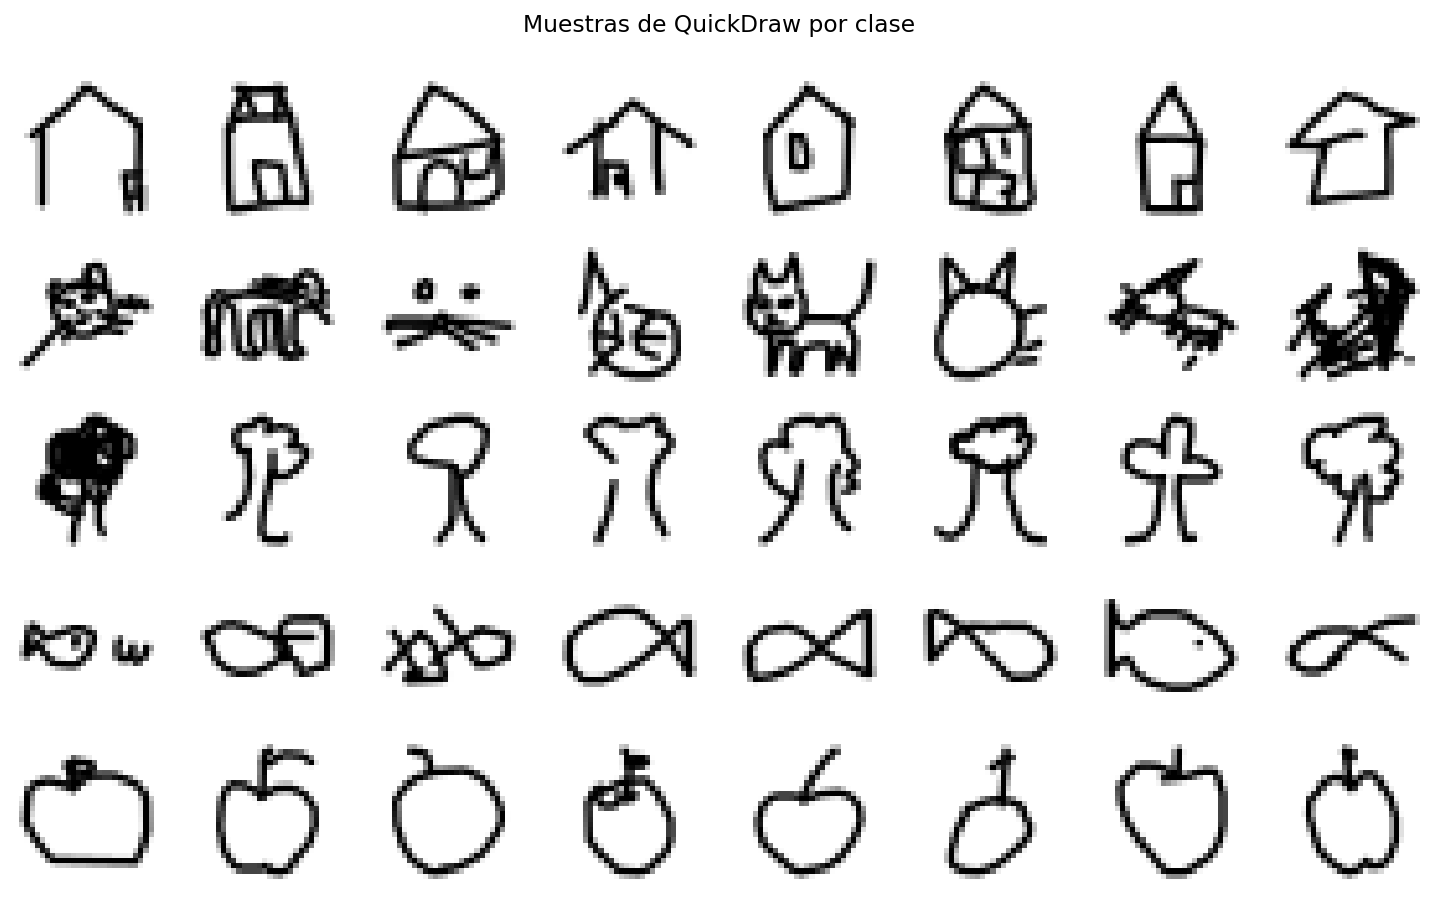

In [2]:
data = np.load(DATA_PATH)
x_train = data["x_train"].astype(np.float32) / 255.0
y_train = data["y_train"]
x_val = data["x_val"].astype(np.float32) / 255.0
y_val = data["y_val"]
class_names = data["class_names"].tolist()

print("x_train:", x_train.shape)
print("x_val:", x_val.shape)
print("clases:", class_names)

fig, axes = plt.subplots(len(class_names), 8, figsize=(10.5, 6.4))
for class_id, name in enumerate(class_names):
    idx = np.where(y_train == class_id)[0][:8]
    for j, image_idx in enumerate(idx):
        ax = axes[class_id, j]
        ax.imshow(x_train[image_idx], cmap="gray_r", vmin=0, vmax=1)
        ax.axis("off")
        if j == 0:
            ax.set_ylabel(name, rotation=0, labelpad=26, va="center")
fig.suptitle("Muestras de QuickDraw por clase", y=0.995)
fig.tight_layout()

## PCA como autoencoder lineal

Para una matriz de datos centrada $X_c$, PCA busca direcciones ortonormales que capturan máxima varianza. Si $W_m\in\mathbb{R}^{m\times d}$ contiene las primeras $m$ componentes principales, la codificación y decodificación lineales son

$$
z=(x-\mu)W_m^\top,
\qquad
\hat{x}=zW_m+\mu.
$$

Esta formulación es un autoencoder lineal con una restricción fuerte: el codificador y decodificador están determinados por una base ortogonal. Un autoencoder neural moderno relaja esa restricción y aprende representaciones no lineales.

In [3]:
PCA_SAMPLES = 10_000
MAX_COMPONENTS = 128

flat_train = x_train.reshape(len(x_train), -1)
flat_val = x_val.reshape(len(x_val), -1)

subset_idx = rng.choice(len(flat_train), size=PCA_SAMPLES, replace=False)
X = flat_train[subset_idx]
pixel_mean = X.mean(axis=0, keepdims=True)
X_centered = X - pixel_mean

start = time.perf_counter()
covariance = (X_centered.T @ X_centered) / (PCA_SAMPLES - 1)
eigenvalues, eigenvectors = np.linalg.eigh(covariance)
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]
components = eigenvectors[:, :MAX_COMPONENTS].T.astype(np.float32)
explained_ratio = eigenvalues / np.maximum(eigenvalues.sum(), 1e-12)
elapsed = time.perf_counter() - start

print(f"PCA ajustado con {PCA_SAMPLES} imágenes")
print(f"Dimensión original: {flat_train.shape[1]}")
print(f"Componentes retenidas: {MAX_COMPONENTS}")
print(f"Tiempo de ajuste: {elapsed:.2f} s")

PCA ajustado con 10000 imágenes
Dimensión original: 784
Componentes retenidas: 128
Tiempo de ajuste: 0.18 s


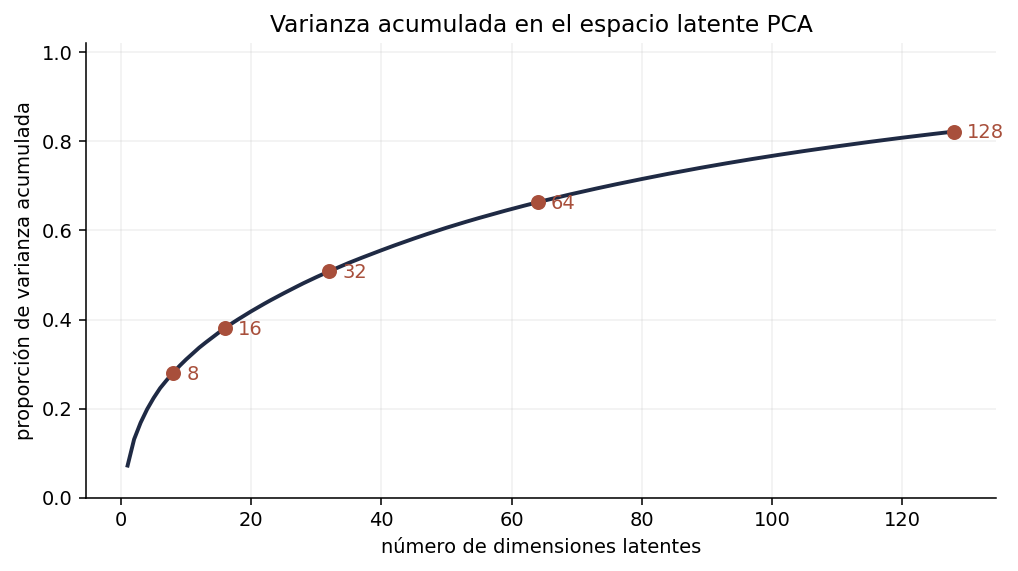

In [4]:
cumulative = np.cumsum(explained_ratio)
dims_to_mark = [8, 16, 32, 64, 128]

fig, ax = plt.subplots(figsize=(7.4, 4.2))
ax.plot(np.arange(1, MAX_COMPONENTS + 1), cumulative[:MAX_COMPONENTS], color="#1f2a44", linewidth=2.0)
for d in dims_to_mark:
    ax.scatter([d], [cumulative[d - 1]], s=45, color="#a84f3b", zorder=3)
    ax.text(d + 2, cumulative[d - 1] - 0.015, f"{d}", fontsize=10, color="#a84f3b")
ax.set_title("Varianza acumulada en el espacio latente PCA")
ax.set_xlabel("número de dimensiones latentes")
ax.set_ylabel("proporción de varianza acumulada")
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.18)
fig.tight_layout()

La varianza explicada no mide calidad perceptual completa. Aun así, ofrece una señal útil: muchas coordenadas del espacio de píxeles son redundantes o altamente correlacionadas. La compresión latente aprovecha esa estructura.

## Reconstrucción desde latentes

Reconstruir desde pocas componentes revela el compromiso central: menor dimensión reduce costo, pero también descarta información. En modelos modernos se busca que el espacio latente conserve estructura perceptual suficiente para que el decodificador pueda producir imágenes convincentes.

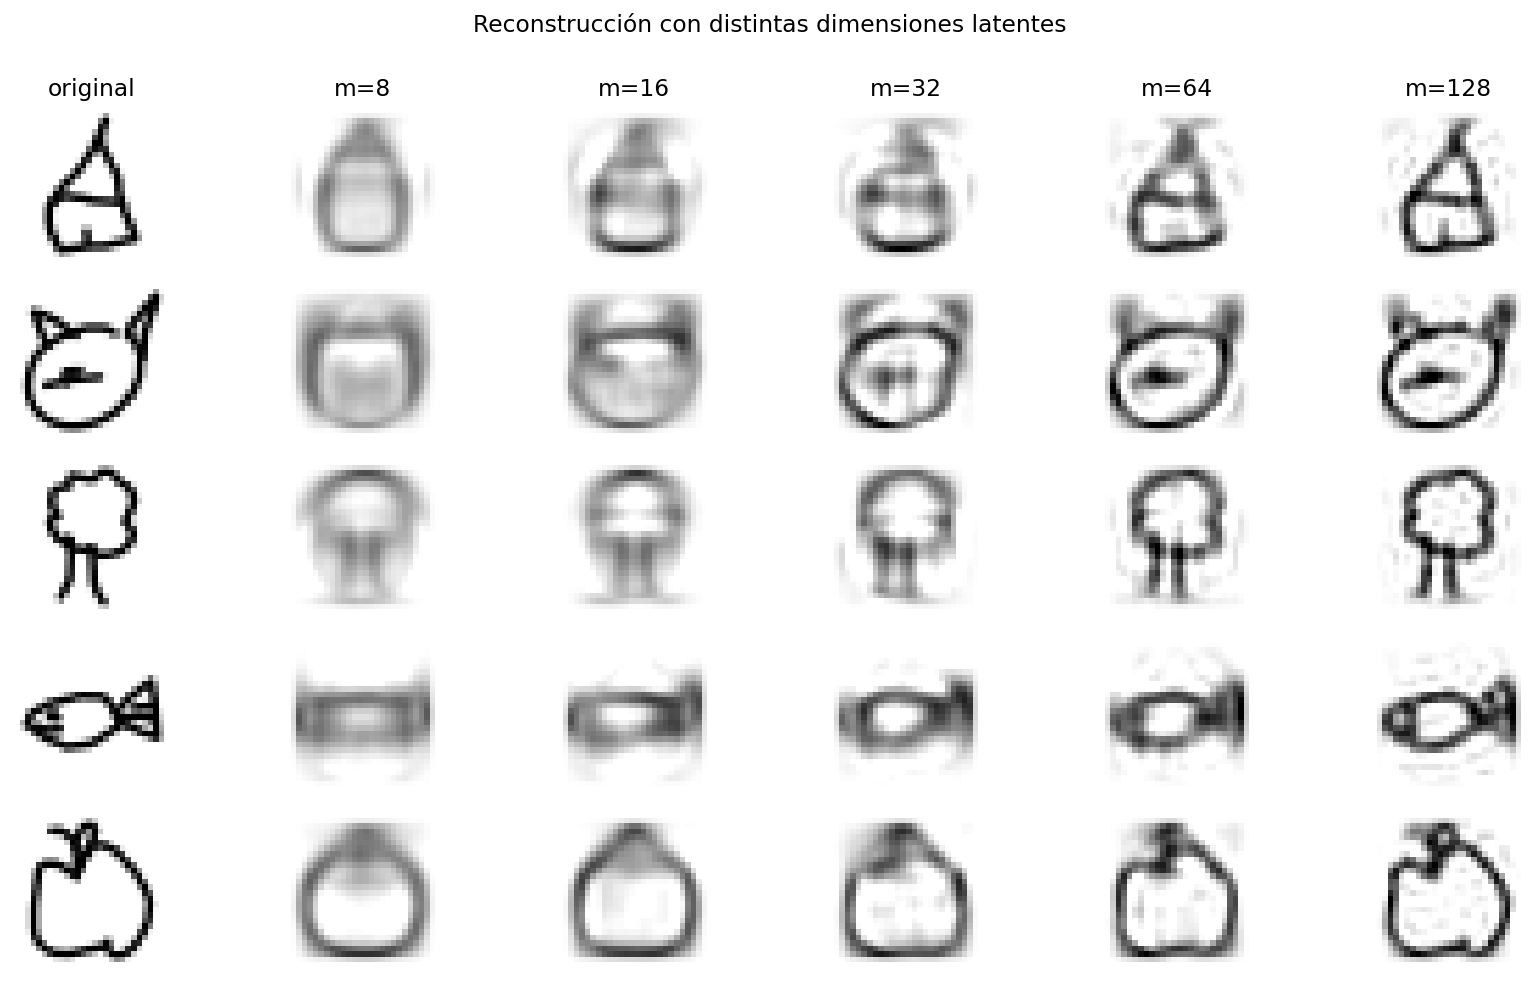

In [5]:
def encode_pca(images_flat, n_components):
    centered = images_flat - pixel_mean
    return centered @ components[:n_components].T


def decode_pca(latents, n_components):
    reconstruction = latents @ components[:n_components] + pixel_mean
    return np.clip(reconstruction, 0.0, 1.0)


selected = []
for class_id in range(len(class_names)):
    selected.append(np.where(y_val == class_id)[0][0])
selected = np.array(selected)
originals = flat_val[selected]

dims = [8, 16, 32, 64, 128]
fig, axes = plt.subplots(len(selected), len(dims) + 1, figsize=(12.2, 7.0))
for row, image_idx in enumerate(selected):
    axes[row, 0].imshow(flat_val[image_idx].reshape(28, 28), cmap="gray_r", vmin=0, vmax=1)
    axes[row, 0].set_ylabel(class_names[y_val[image_idx]], rotation=0, labelpad=26, va="center")
    axes[row, 0].set_title("original" if row == 0 else "")
    axes[row, 0].axis("off")
    for col, d in enumerate(dims, start=1):
        z = encode_pca(flat_val[[image_idx]], d)
        rec = decode_pca(z, d).reshape(28, 28)
        axes[row, col].imshow(rec, cmap="gray_r", vmin=0, vmax=1)
        axes[row, col].set_title(f"m={d}" if row == 0 else "")
        axes[row, col].axis("off")
fig.suptitle("Reconstrucción con distintas dimensiones latentes", y=0.995)
fig.tight_layout()

## Geometría del espacio latente

Al proyectar las imágenes sobre las dos primeras componentes principales, cada punto representa una imagen completa. El plano no captura toda la información, pero permite observar organización global. Las clases no necesariamente quedan separadas de forma perfecta porque PCA no usa etiquetas; solo maximiza varianza.

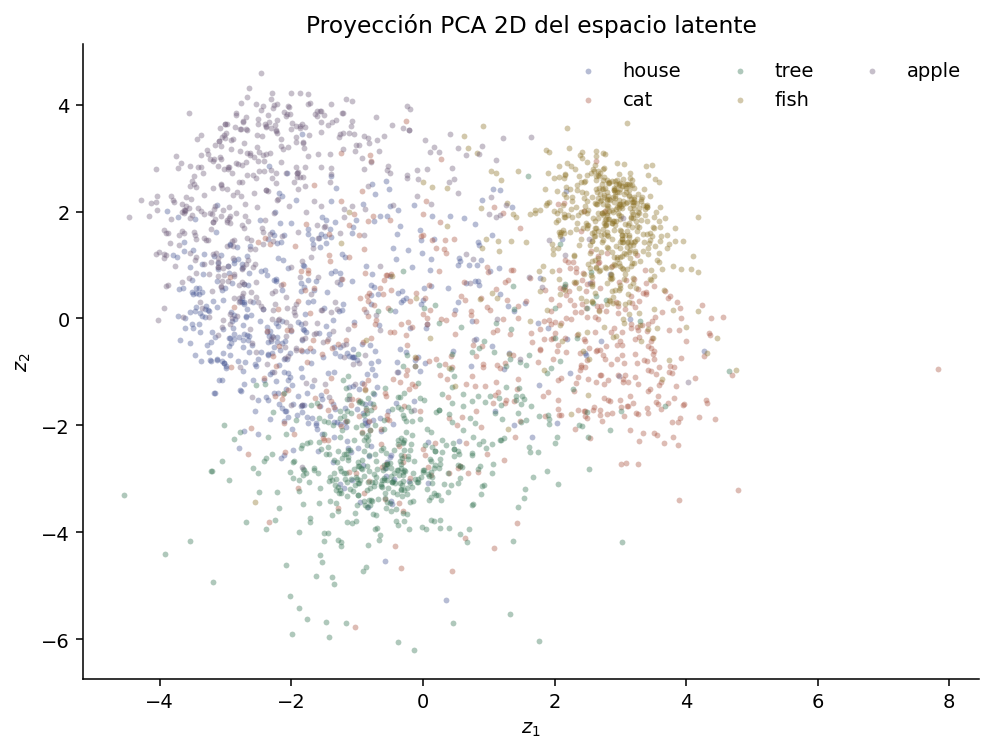

In [6]:
val_subset = 2_500
val_idx = rng.choice(len(flat_val), size=val_subset, replace=False)
z2 = encode_pca(flat_val[val_idx], 2)
labels = y_val[val_idx]

palette = ["#3f4f8f", "#a84f3b", "#2f6f4e", "#8a6f22", "#6b5876"]
fig, ax = plt.subplots(figsize=(7.2, 5.5))
for class_id, name in enumerate(class_names):
    mask = labels == class_id
    ax.scatter(z2[mask, 0], z2[mask, 1], s=9, alpha=0.38, color=palette[class_id], linewidths=0, label=name)
ax.set_title("Proyección PCA 2D del espacio latente")
ax.set_xlabel("$z_1$")
ax.set_ylabel("$z_2$")
ax.legend(frameon=False, ncol=3, loc="upper right")
fig.tight_layout()

## Interpolación latente

Una prueba cualitativa de un espacio latente es interpolar entre dos códigos. En un buen espacio de representación, los puntos intermedios deberían producir transiciones razonables. Con PCA el resultado es lineal y limitado, pero permite ver la operación con total transparencia matemática.

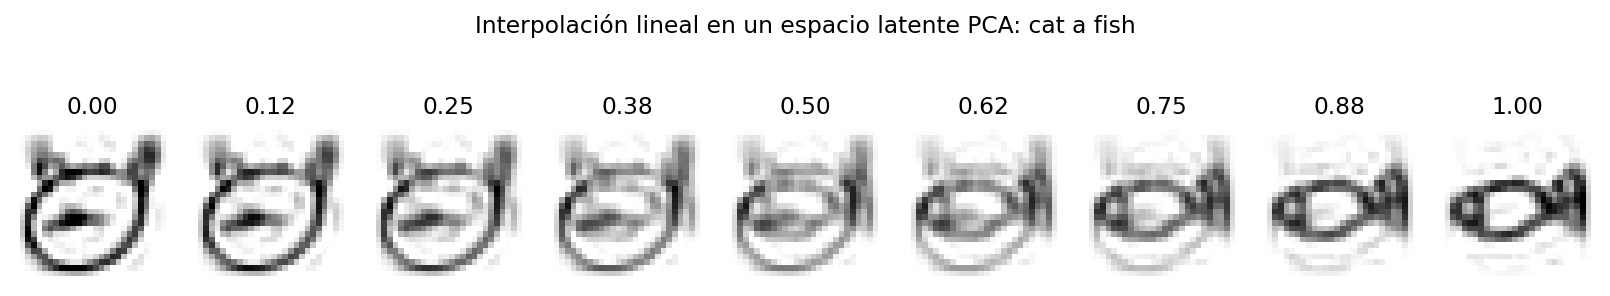

In [7]:
dim_interp = 128
idx_a = np.where(y_val == class_names.index("cat"))[0][0]
idx_b = np.where(y_val == class_names.index("fish"))[0][0]
z_a = encode_pca(flat_val[[idx_a]], dim_interp)
z_b = encode_pca(flat_val[[idx_b]], dim_interp)

alphas = np.linspace(0, 1, 9)
fig, axes = plt.subplots(1, len(alphas), figsize=(11.6, 2.2))
for ax, alpha in zip(axes, alphas):
    z = (1 - alpha) * z_a + alpha * z_b
    rec = decode_pca(z, dim_interp).reshape(28, 28)
    ax.imshow(rec, cmap="gray_r", vmin=0, vmax=1)
    ax.set_title(f"{alpha:.2f}")
    ax.axis("off")
fig.suptitle("Interpolación lineal en un espacio latente PCA: cat a fish", y=1.04)
fig.tight_layout()

## Difusión directa en latentes

Si $z_0$ es el código de una imagen, podemos añadir ruido directamente en el espacio latente:

$$
z_t
=
\sqrt{\bar{\alpha}_t}z_0
+
\sqrt{1-\bar{\alpha}_t}\epsilon.
$$

Decodificar esos latentes ruidosos no es el procedimiento de generación final; solo permite ver qué significa degradar una representación comprimida. En un modelo latente real, la red aprende a revertir este proceso antes de decodificar.

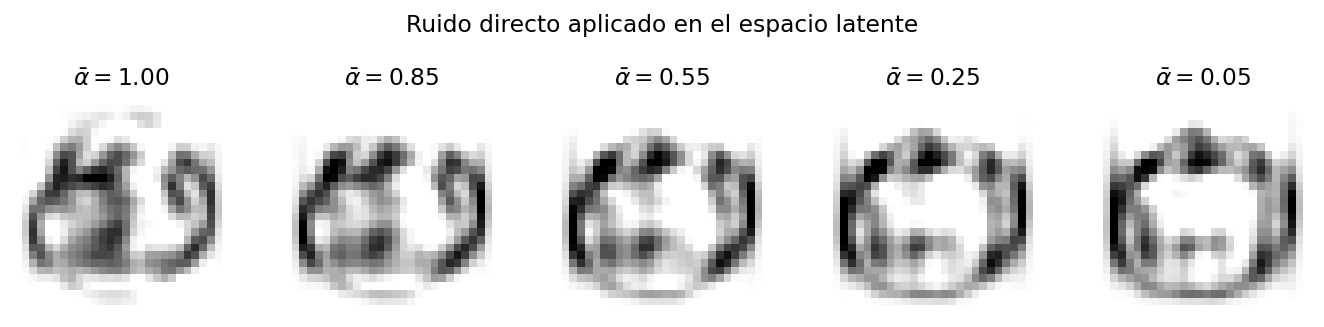

In [8]:
dim_latent = 64
image_idx = np.where(y_val == class_names.index("cat"))[0][5]
z0 = encode_pca(flat_val[[image_idx]], dim_latent)
latent_std = np.sqrt(eigenvalues[:dim_latent] + 1e-8).reshape(1, -1).astype(np.float32)
z0_standard = z0 / latent_std
eps = rng.normal(size=z0_standard.shape).astype(np.float32)
alpha_bars = [1.0, 0.85, 0.55, 0.25, 0.05]

fig, axes = plt.subplots(1, len(alpha_bars), figsize=(9.8, 2.2))
for ax, alpha_bar in zip(axes, alpha_bars):
    zt_standard = np.sqrt(alpha_bar) * z0_standard + np.sqrt(1.0 - alpha_bar) * eps
    zt = zt_standard * latent_std
    rec = decode_pca(zt, dim_latent).reshape(28, 28)
    ax.imshow(rec, cmap="gray_r", vmin=0, vmax=1)
    ax.set_title(fr"$\bar{{\alpha}}={alpha_bar:.2f}$")
    ax.axis("off")
fig.suptitle("Ruido directo aplicado en el espacio latente", y=1.04)
fig.tight_layout()

## Backbones generativos

El autoencoder define el espacio donde se modela la distribución, pero no define por sí solo el modelo generativo. La red que predice ruido, score o velocidad puede tomar varias formas.

Una U-Net conserva estructura espacial mediante convoluciones, reducciones de resolución y conexiones laterales. Esta arquitectura fue natural para difusión en imágenes porque mezcla información local y global sin perder completamente la geometría espacial.

Un diffusion transformer organiza la representación como una secuencia de parches o tokens y usa bloques transformer. Esta alternativa gana importancia cuando el escalamiento, el condicionamiento y la capacidad global del modelo son centrales.

En ambos casos, la red no genera por una sola pasada directa. Participa dentro de un procedimiento generativo iterativo o continuo: recibe una representación ruidosa, un tiempo y una condición; devuelve una predicción que guía el siguiente estado.

## Condicionamiento

La condición $c$ puede ser una etiqueta de clase, un texto, otra imagen, una máscara o una estructura espacial. En notebooks anteriores usamos etiquetas. En sistemas texto-imagen, el texto se transforma primero en embeddings mediante un codificador textual. Después esos embeddings condicionan la red generativa mediante mecanismos como atención cruzada, concatenación o normalizaciones adaptativas.

La formulación general conserva la misma forma:

$$
\epsilon_\theta(z_t,t,c).
$$

Lo que cambia es la naturaleza de $c$ y la forma en que la arquitectura permite que esa información modifique la predicción.

## Relación con los notebooks anteriores

Los notebooks 02 a 05 explicaron el mecanismo DDPM: ruido directo, objetivo de denoising y muestreo inverso. Los notebooks 07 y 08 mostraron condicionamiento y guidance. El notebook 09 reinterpretó la predicción de ruido como estimación de score. El notebook 10 mostró que también podemos pensar en campos de velocidad y transporte.

Este notebook no reemplaza esas ideas. Las ubica dentro de una arquitectura completa. En un sistema moderno, el corazón matemático del modelo sigue siendo una transformación entre distribuciones; la arquitectura decide en qué espacio se realiza esa transformación y cómo entra la condición.

## Limitaciones del experimento

PCA es lineal, no perceptual y no está entrenado para producir imágenes realistas. Por eso sus reconstrucciones pueden verse borrosas o mezcladas. Un autoencoder moderno aprende transformaciones no lineales y suele entrenarse con pérdidas adicionales para preservar estructura visual.

Aun con esa limitación, el experimento deja clara la idea central: si una imagen puede representarse mediante un código más pequeño que conserva información relevante, entonces el modelo generativo puede operar sobre ese código. La ganancia no es solo computacional; también cambia la manera en que se diseñan arquitecturas, condiciones y procedimientos de muestreo.

## Referencias conceptuales

La estructura discutida aquí conecta tres líneas de trabajo: U-Net como arquitectura encoder-decoder con conexiones laterales, latent diffusion como difusión sobre representaciones comprimidas, y diffusion transformers como alternativa basada en tokens y atención.

Referencias recomendadas:

- Ronneberger, Fischer y Brox. [*U-Net: Convolutional Networks for Biomedical Image Segmentation*](https://arxiv.org/abs/1505.04597).
- Rombach, Blattmann, Lorenz, Esser y Ommer. [*High-Resolution Image Synthesis with Latent Diffusion Models*](https://arxiv.org/abs/2112.10752).
- Peebles y Xie. [*Scalable Diffusion Models with Transformers*](https://arxiv.org/abs/2212.09748).

## Preguntas de discusión

1. ¿Qué información se pierde al pasar del espacio de píxeles al espacio latente?
2. ¿Por qué PCA puede interpretarse como un autoencoder lineal y por qué esa interpretación es insuficiente para modelos perceptuales modernos?
3. ¿Qué cambia al aplicar difusión sobre $z_t$ en lugar de $x_t$, desde el punto de vista de costo computacional y arquitectura?
4. ¿Por qué una U-Net y un diffusion transformer pueden cumplir el mismo rol funcional aunque tengan arquitecturas distintas?
5. ¿Qué papel cumple la condición $c$ en una arquitectura generativa moderna?

## Síntesis

**Resultado conceptual.** Los modelos generativos modernos no se explican solo por la pérdida de entrenamiento. También dependen de una arquitectura que separa representación, dinámica generativa, condicionamiento y decodificación. La difusión latente reemplaza el modelado directo en píxeles por modelado en un espacio comprimido donde el costo de entrenamiento y muestreo puede reducirse.

**Cierre del curso.** El recorrido completo muestra una progresión: distribución de datos, ruido gaussiano, difusión directa, denoising, DDPM, muestreo, condicionamiento, guidance, score matching, flow matching y espacios latentes. Con esta base, el estudiante puede leer trabajos modernos sin tratarlos como cajas negras.